In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scanpy as sc
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_RUNS        = 10
N_CLUSTERS    = 3   # number of clusters for reproducibility analysis
CONCENTRATION = '10'
TCDG          = 1000
RESULTS_DIR   = 'results/reproducibility_drug'

# Match exactly the training params from gbm_run_conditions_bt333_with_T_cell_conditions_figures_10um.ipynb
SHERLOCK_KWARGS = dict(
    batch_size     = 4096,
    num_workers    = 0,
    num_epochs     = 500,
    use_conditions = True,
    validate_every = 50,
    l0_lambda      = 300,
    lr             = 1e-2,
    patience       = 500,
    rho_init       = False,
    ntc_lambda     = 1.0,
    latent_dim     = 8,
)

os.makedirs(f'{RESULTS_DIR}/figures',  exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/matrices', exist_ok=True)
print(f'Device: {DEVICE}  Results: {RESULTS_DIR}')

Device: cuda  Results: results/reproducibility_drug


## Data loading

In [4]:
slk.configs.reset_config()
slk.configs.set_config('ntc_label',      'DMSO')
slk.configs.set_config('pert_key',       'drug')
slk.configs.set_config('treatment_key',  'tcell_treatment')
slk.configs.set_config('untreated_label','NoT')

data = sc.read_h5ad(f'../../datasets/gbm/bt333_degs_tcell_{CONCENTRATION}_{TCDG}.h5ad')
data = data[~data.obs['drug'].isna()].copy()
data = data[
    (data.obs['concentration'] == CONCENTRATION) | (data.obs['drug'] == 'DMSO')
].copy()

slk.pp.slk_prepare_data(
    data, pert_key='drug', ntc_label='DMSO', inplace=True,
    treatment_key='tcell_treatment', untreated_label='NoT', force=True
)

p_key     = slk.configs.get_config('pert_key')
NTC       = slk.configs.get_config('ntc_label')
c_key     = slk.configs.get_config('treatment_key')
c_ntc_key = slk.configs.get_config('untreated_label')

print(f'Cells: {data.n_obs}   Genes: {data.n_vars}')
print(f'Perturbations (non-DMSO): {data.obs[p_key].nunique() - 1}')
print(f'Conditions: {sorted(data.obs[c_key].unique())}')

Cells: 35511   Genes: 2894
Perturbations (non-DMSO): 11
Conditions: ['0.5T', 'NoT']


In [5]:
slk.pp.treat_effect(
    data, label_col='drug', control_label='DMSO',
    method='perturbseq', inplace=True, key='treat_effect',
)

100%|██████████| 11/11 [00:01<00:00,  7.86it/s]


## Part 1 — Reproducibility loop

Train `N_RUNS` independent models with the same hyper-parameters.  
Per run we save:
- `W`, `rho_corr` / `z_corr` matrices
- Counterfactual effect sizes per condition (for bipartite reproducibility)
- Condition-perturbation interaction matrix (CFS)
- ATE correlation + full ATE predictions (for cross-run comparison)

The single best-ATE model is saved to `best_model.pth` for final figures.

> **Tip**: skip this section if matrices already exist and jump to *Part 2 — Load matrices*.

In [6]:
use_rerun = True

for run in range(N_RUNS):
    out_path = f'{RESULTS_DIR}/matrices/run_{run}.npz'
    if os.path.exists(out_path) and use_rerun:
        print(f'Run {run+1}: already saved, skipping.')
        continue

    print(f"\n{'='*50}\nDrug run {run+1}/{N_RUNS}\n{'='*50}")
    out   = slk.tl.run_single(data, device=DEVICE, seed=run, **SHERLOCK_KWARGS)
    model = out['model']

    slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    res = data.uns['results']

    W          = np.asarray(res['W'],         dtype=float)
    rho_corr   = np.asarray(res['rho_corr'],  dtype=float)
    z_corr     = np.asarray(res['z_corr'],    dtype=float)
    rho_perts  = np.asarray(res['rho_perts'])
    cond_names = list(res['conditions'])
    cf_sizes   = [np.asarray(cf, dtype=float) for cf in res['counterfactual_effect_size']]
    cfs_mat    = np.asarray(res['condition_perturbation_interaction'], dtype=float)

    # ATE: predicted vs observed treatment effect correlation
    ate      = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    ate_r    = float(ate['corr'])
    pred_df  = ate['predicted_df']

    # ev_sig qvals per condition (significant gene-set Jaccard reproducibility)
    for ci in range(len(cond_names)):
        slk.tl.ev_sig(data, cond_idx=ci)
        qvals = np.asarray(data.uns['results']['ev_results'][ci]['qvals'], dtype=float)
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy', qvals)

    # Save matrices
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_W.npy',        W)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy', rho_corr)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy',   z_corr)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt',  rho_perts,  fmt='%s')
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt',  cond_names, fmt='%s')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy',  cfs_mat)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt',  [ate_r],    fmt='%.6f')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy', pred_df.values)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', list(pred_df.index), fmt='%s')
    for ci, cf in enumerate(cf_sizes):
        np.save(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy', cf)
    np.savez(out_path)  # sentinel

    # Keep the best-ATE model
    best_r_path = f'{RESULTS_DIR}/matrices/best_ate_r.txt'
    current_best = float(np.loadtxt(best_r_path)) if os.path.exists(best_r_path) else -np.inf
    if ate_r > current_best:
        slk.tl.save_results(out, f'{RESULTS_DIR}/matrices/best_model.pth')
        np.savetxt(best_r_path, [ate_r], fmt='%.6f')
        np.savetxt(f'{RESULTS_DIR}/matrices/best_run.txt', [run], fmt='%d')
        print(f'  New best model: ATE r={ate_r:.4f}')

    print(f'  Saved run {run+1} (ATE r={ate_r:.4f})')

print('\nTraining complete.')


Drug run 1/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [08:00<00:00,  1.04it/s, ATE=0.7051, CE=0.1508, ELBO=1839.5851, KLw=1.00, R2_ntc=0.7198, R2_p=0.7508, acc=0.946, pi25=0.01, pi99=1.00, tau=0.300]


  New best model: ATE r=0.7170
  Saved run 1 (ATE r=0.7170)

Drug run 2/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [07:04<00:00,  1.18it/s, ATE=0.7211, CE=0.1284, ELBO=1838.4546, KLw=1.00, R2_ntc=0.7478, R2_p=0.7598, acc=0.956, pi25=0.01, pi99=1.00, tau=0.300]


  New best model: ATE r=0.7180
  Saved run 2 (ATE r=0.7180)

Drug run 3/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:58<00:00,  1.20it/s, ATE=0.7028, CE=0.2121, ELBO=1837.7872, KLw=1.00, R2_ntc=0.6868, R2_p=0.7548, acc=0.927, pi25=0.01, pi99=1.00, tau=0.300]


  Saved run 3 (ATE r=0.7028)

Drug run 4/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:58<00:00,  1.19it/s, ATE=0.7114, CE=0.1616, ELBO=1840.9166, KLw=1.00, R2_ntc=0.6046, R2_p=0.7441, acc=0.943, pi25=0.03, pi99=1.00, tau=0.300]


  Saved run 4 (ATE r=0.7068)

Drug run 5/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:56<00:00,  1.20it/s, ATE=0.7338, CE=0.2255, ELBO=1840.2045, KLw=1.00, R2_ntc=0.6452, R2_p=0.7501, acc=0.923, pi25=0.01, pi99=1.00, tau=0.300]


  Saved run 5 (ATE r=0.7133)

Drug run 6/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:59<00:00,  1.19it/s, ATE=0.7150, CE=0.2335, ELBO=1840.9135, KLw=1.00, R2_ntc=0.7001, R2_p=0.7313, acc=0.920, pi25=0.02, pi99=1.00, tau=0.300]


  Saved run 6 (ATE r=0.6972)

Drug run 7/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:56<00:00,  1.20it/s, ATE=0.7133, CE=0.1593, ELBO=1840.8372, KLw=1.00, R2_ntc=0.6641, R2_p=0.7466, acc=0.945, pi25=0.09, pi99=1.00, tau=0.300]


  Saved run 7 (ATE r=0.7178)

Drug run 8/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:54<00:00,  1.21it/s, ATE=0.7107, CE=0.1700, ELBO=1840.8359, KLw=1.00, R2_ntc=0.7388, R2_p=0.7497, acc=0.939, pi25=0.02, pi99=1.00, tau=0.300]


  Saved run 8 (ATE r=0.7127)

Drug run 9/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:54<00:00,  1.21it/s, ATE=0.7221, CE=0.1866, ELBO=1838.8318, KLw=1.00, R2_ntc=0.7458, R2_p=0.7415, acc=0.936, pi25=0.01, pi99=1.00, tau=0.300]


  New best model: ATE r=0.7222
  Saved run 9 (ATE r=0.7222)

Drug run 10/10
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [06:54<00:00,  1.21it/s, ATE=0.7319, CE=0.1629, ELBO=1839.1869, KLw=1.00, R2_ntc=0.7638, R2_p=0.7559, acc=0.943, pi25=0.01, pi99=1.00, tau=0.300]


  New best model: ATE r=0.7265
  Saved run 10 (ATE r=0.7265)

Training complete.


## Part 2 — Load saved matrices

Re-entry point: run from here if matrices already exist.

In [7]:
run_results = []
for run in range(N_RUNS):
    W          = np.load(f'{RESULTS_DIR}/matrices/run_{run}_W.npy')
    rho_corr   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy')
    z_corr     = np.load(f'{RESULTS_DIR}/matrices/run_{run}_z_corr.npy')
    rho_perts  = np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt',    dtype=str, ndmin=1)
    cond_names = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_conds.txt', dtype=str, ndmin=1))
    cfs_mat    = np.load(f'{RESULTS_DIR}/matrices/run_{run}_cfs_mat.npy')
    ate_r      = float(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt'))
    ate_pred   = np.load(f'{RESULTS_DIR}/matrices/run_{run}_ate_pred.npy')
    ate_perts  = list(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_perts.txt', dtype=str, ndmin=1))
    n_conds    = len(cond_names)
    cf_sizes   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_cf_{ci}.npy') for ci in range(n_conds)]
    ev_qvals   = [np.load(f'{RESULTS_DIR}/matrices/run_{run}_evqvals_{ci}.npy') for ci in range(n_conds)]

    run_results.append(dict(
        run=run, W=W, rho_corr=rho_corr, z_corr=z_corr,
        rho_perts=rho_perts, cond_names=cond_names,
        cfs_mat=cfs_mat, ate_r=ate_r, ate_pred=ate_pred,
        ate_perts=ate_perts, cf_sizes=cf_sizes, ev_qvals=ev_qvals,
    ))
    print(f'Run {run+1}: ATE r={ate_r:.4f}  W {W.shape}  perts {len(rho_perts)}')

all_perts   = sorted(run_results[0]['rho_perts'].tolist())
cond_names  = run_results[0]['cond_names']
all_ate_r   = [r['ate_r'] for r in run_results]
best_run_id = int(np.argmax(all_ate_r))

print(f'\nATE r per run: {[f"{r:.4f}" for r in all_ate_r]}')
print(f'Mean ± Std: {np.mean(all_ate_r):.4f} ± {np.std(all_ate_r):.4f}')
print(f'Best run: {best_run_id+1} (ATE r={all_ate_r[best_run_id]:.4f})')
print(f'Conditions: {cond_names}')

Run 1: ATE r=0.7170  W (11, 8)  perts 11
Run 2: ATE r=0.7180  W (11, 8)  perts 11
Run 3: ATE r=0.7028  W (11, 8)  perts 11
Run 4: ATE r=0.7068  W (11, 8)  perts 11
Run 5: ATE r=0.7133  W (11, 8)  perts 11
Run 6: ATE r=0.6972  W (11, 8)  perts 11
Run 7: ATE r=0.7178  W (11, 8)  perts 11
Run 8: ATE r=0.7127  W (11, 8)  perts 11
Run 9: ATE r=0.7222  W (11, 8)  perts 11
Run 10: ATE r=0.7265  W (11, 8)  perts 11

ATE r per run: ['0.7170', '0.7180', '0.7028', '0.7068', '0.7133', '0.6972', '0.7178', '0.7127', '0.7222', '0.7265']
Mean ± Std: 0.7134 ± 0.0085
Best run: 10 (ATE r=0.7265)
Conditions: [np.str_('NoT'), np.str_('0.5T')]


## Helper functions

In [8]:
def align_groups_to_reference(ref_ng, tgt_ng):
    """Hungarian-match tgt group labels to ref group labels by shared membership."""
    common = set(ref_ng.index) & set(tgt_ng.index)
    if not common:
        return {}
    ref_labels = sorted(ref_ng['group'].unique())
    tgt_labels = sorted(tgt_ng['group'].unique())
    C = np.zeros((len(ref_labels), len(tgt_labels)), dtype=int)
    for gene in common:
        ri = ref_labels.index(ref_ng.loc[gene, 'group'])
        ti = tgt_labels.index(tgt_ng.loc[gene, 'group'])
        C[ri, ti] += 1
    row_ind, col_ind = linear_sum_assignment(C.max() - C)
    mapping = {tgt_labels[j]: ref_labels[i] for i, j in zip(row_ind, col_ind)}
    for tl in tgt_labels:
        if tl not in mapping:
            genes_in_tl = [g for g in tgt_ng.index if tgt_ng.loc[g, 'group'] == tl and g in common]
            if genes_in_tl:
                vote = {}
                for g in genes_in_tl:
                    rg = ref_ng.loc[g, 'group']
                    vote[rg] = vote.get(rg, 0) + 1
                mapping[tl] = max(vote, key=vote.get)
    return mapping


def cluster_all_runs(run_results, n_clusters, all_perts):
    clustered = []
    for rr in run_results:
        groups       = slk.tl.cluster_rho(
            data, t=n_clusters, rho_corr=rr['z_corr'],
            criterion='maxclust', show=False,
        )
        named_groups = slk.tl.group2name(groups, list(rr['rho_perts']))
        clustered.append({**rr, 'groups': groups, 'named_groups': named_groups})
    return clustered


def compute_confidence(clustered_runs, all_perts):
    ref_ng     = clustered_runs[0]['named_groups']
    ref_groups = sorted(ref_ng['group'].unique())
    n_runs     = len(clustered_runs)

    aligned = {p: [] for p in all_perts}
    for rr in clustered_runs:
        mapping = ({g: g for g in ref_groups} if rr['run'] == 0
                   else align_groups_to_reference(ref_ng, rr['named_groups']))
        ng = rr['named_groups']
        for p in all_perts:
            if p in ng.index:
                aligned[p].append(mapping.get(ng.loc[p, 'group'], -1))
            else:
                aligned[p].append(-1)

    group_cols = [f'Group {g}' for g in ref_groups]
    rows = []
    for p in all_perts:
        asn  = aligned[p]
        row  = {f'Group {g}': asn.count(g) / n_runs for g in ref_groups}
        row['modal_group'] = f'Group {max(ref_groups, key=lambda g: asn.count(g))}'
        row['max_conf']    = max(asn.count(g) for g in ref_groups) / n_runs
        row['unassigned']  = asn.count(-1) / n_runs
        rows.append({'perturbation': p, **row})

    df = pd.DataFrame(rows).set_index('perturbation')
    return df.sort_values(['modal_group', 'max_conf'], ascending=[True, False]), group_cols


def jaccard(labels_i, labels_j):
    n      = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


def compute_pairwise_similarity(run_results, clustered_runs, all_perts):
    """W co-activation, rho, and cluster Jaccard for every run pair."""
    n_runs = len(run_results)
    pairs  = list(combinations(range(n_runs), 2))
    w_corrs, rho_corrs, jac_raw, jac_aln = [], [], [], []

    for i, j in pairs:
        ri, rj = run_results[i], run_results[j]

        Ci   = ri['W'] @ ri['W'].T
        Cj   = rj['W'] @ rj['W'].T
        triu = np.triu_indices(Ci.shape[0], k=1)
        w_corrs.append(pearsonr(Ci[triu], Cj[triu])[0])

        fi, fj = ri['z_corr'][triu], rj['z_corr'][triu]
        valid  = np.isfinite(fi) & np.isfinite(fj)
        rho_corrs.append(pearsonr(fi[valid], fj[valid])[0])

        ci_r, cj_r = clustered_runs[i], clustered_runs[j]
        jac_raw.append(jaccard(ci_r['groups'].astype(object), cj_r['groups'].astype(object)))

        ng_i, ng_j = ci_r['named_groups'], cj_r['named_groups']
        common     = [p for p in all_perts if p in ng_i.index and p in ng_j.index]
        mapping_ij = align_groups_to_reference(ng_i, ng_j)
        mp_i = np.array([ng_i.loc[p, 'group'] for p in common], dtype=object)
        mp_j = np.array([mapping_ij.get(ng_j.loc[p, 'group'], -1) for p in common], dtype=object)
        valid_mask = mp_j != -1
        jac_aln.append(jaccard(mp_i[valid_mask], mp_j[valid_mask]))

    return pairs, w_corrs, rho_corrs, jac_raw, jac_aln

## Part 3 — W and rho reproducibility

For every run pair:
- **W co-activation Pearson r**: upper triangle of `W @ Wᵀ`
- **rho Pearson r**: upper triangle of `z_corr`

In [9]:
clustered_runs = cluster_all_runs(run_results, N_CLUSTERS, all_perts)
pairs, w_corrs, rho_corrs, jac_raw, jac_aln = compute_pairwise_similarity(
    run_results, clustered_runs, all_perts
)

print('Pairwise W co-activation Pearson r:')
print(f'  Mean ± Std: {np.mean(w_corrs):.4f} ± {np.std(w_corrs):.4f}')
print(f'  Min / Max : {np.min(w_corrs):.4f} / {np.max(w_corrs):.4f}')

print('\nPairwise rho (z_corr) Pearson r:')
valid_rho = [v for v in rho_corrs if np.isfinite(v)]
print(f'  Mean ± Std: {np.mean(valid_rho):.4f} ± {np.std(valid_rho):.4f}')
print(f'  Min / Max : {np.min(valid_rho):.4f} / {np.max(valid_rho):.4f}')

Pairwise W co-activation Pearson r:
  Mean ± Std: 0.8865 ± 0.0425
  Min / Max : 0.7542 / 0.9581

Pairwise rho (z_corr) Pearson r:
  Mean ± Std: 0.8168 ± 0.0960
  Min / Max : 0.5656 / 0.9372


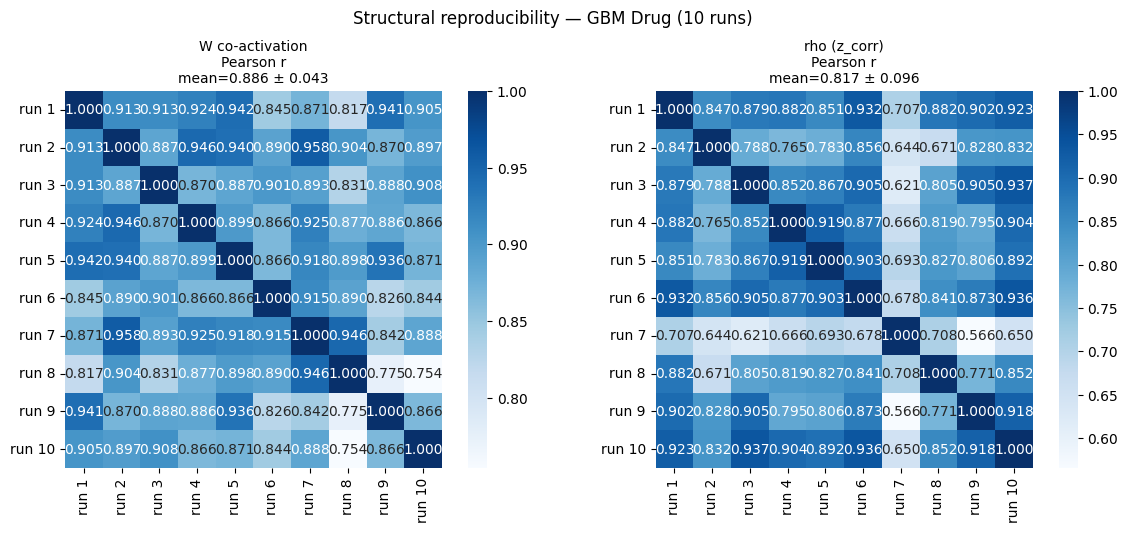

In [10]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,  N_RUNS, pairs)
R_mat  = to_matrix(rho_corrs, N_RUNS, pairs)
run_labels = [f'run {k+1}' for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title in zip(
    axes,
    [W_mat, R_mat],
    ['W co-activation\nPearson r', 'rho (z_corr)\nPearson r'],
):
    off = mat[~np.eye(N_RUNS, dtype=bool)]
    sns.heatmap(
        mat, ax=ax, cmap='Blues', annot=(N_RUNS <= 12), fmt='.3f',
        vmin=np.nanmin(off), vmax=1.0,
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(f'{title}\nmean={np.nanmean(off):.3f} ± {np.nanstd(off):.3f}', fontsize=10)

fig.suptitle(f'Structural reproducibility — GBM Drug ({N_RUNS} runs)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/W_rho_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 4 — Clustering reproducibility (N_CLUSTERS = 3)

Cluster all runs with `N_CLUSTERS` groups.  
Metrics:
- Per-perturbation group **confidence** (fraction of runs in modal group)
- Pairwise **Jaccard** (raw and Hungarian-aligned)
- **Co-membership matrix** (fraction of runs where two perturbations share a cluster)

In [11]:
confidence_df, group_cols = compute_confidence(clustered_runs, all_perts)
P_n      = len(all_perts)
pert_idx = {p: i for i, p in enumerate(all_perts)}

# Co-membership matrix
comembership = np.zeros((P_n, P_n))
for rr in clustered_runs:
    ng           = rr['named_groups']
    perts_in_run = [p for p in all_perts if p in ng.index]
    for pi in perts_in_run:
        gi = ng.loc[pi, 'group']
        for pj in perts_in_run:
            if ng.loc[pj, 'group'] == gi:
                comembership[pert_idx[pi], pert_idx[pj]] += 1
comembership /= N_RUNS
np.fill_diagonal(comembership, 1.0)

print(f'Clustering with N_CLUSTERS={N_CLUSTERS}:')
print(f'  Mean max-confidence : {confidence_df["max_conf"].mean():.3f} ± {confidence_df["max_conf"].std():.3f}')
print(f'  Stable (≥0.8)       : {(confidence_df["max_conf"] >= 0.8).sum()} / {len(confidence_df)}')
print(f'  Pairwise Jaccard (aligned) : {np.nanmean(jac_aln):.3f} ± {np.nanstd(jac_aln):.3f}')
print()
print(confidence_df.round(2).to_string())

Clustering with N_CLUSTERS=3:
  Mean max-confidence : 0.655 ± 0.192
  Stable (≥0.8)       : 3 / 11
  Pairwise Jaccard (aligned) : 0.343 ± 0.135

                     Group 1  Group 2  Group 3 modal_group  max_conf  unassigned
perturbation                                                                    
Zabedosertib             1.0      0.0      0.0     Group 1       1.0         0.0
STK16IN1                 0.7      0.0      0.3     Group 1       0.7         0.0
BAY1217389               0.6      0.0      0.4     Group 1       0.6         0.0
PF06260933               0.6      0.2      0.2     Group 1       0.6         0.0
Abemaciclibmesylate      0.0      0.9      0.1     Group 2       0.9         0.0
Laduviglusib             0.0      0.8      0.2     Group 2       0.8         0.0
Tyrphostin9              0.0      0.6      0.4     Group 2       0.6         0.0
CP673451                 0.2      0.4      0.4     Group 2       0.4         0.0
SGCAAK11                 0.3      0.4      0.

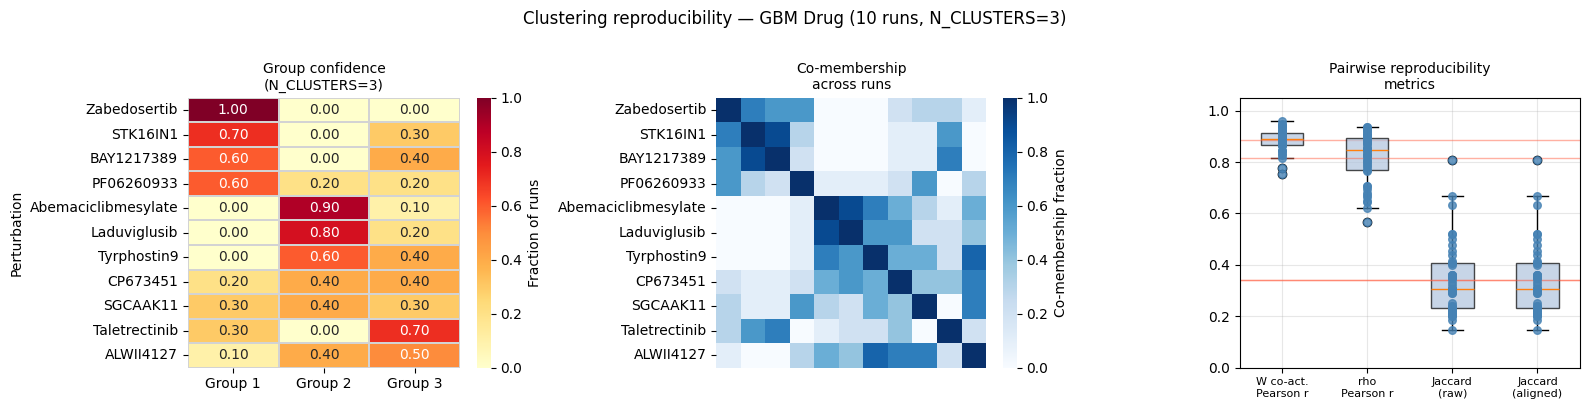

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, max(4, P_n * 0.18 + 2)))

# Confidence heatmap
sns.heatmap(
    confidence_df[group_cols], ax=axes[0],
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': 'Fraction of runs'},
    annot=True, fmt='.2f',
)
axes[0].set_title(f'Group confidence\n(N_CLUSTERS={N_CLUSTERS})', fontsize=10)
axes[0].set_ylabel('Perturbation')

# Co-membership heatmap
sort_order = confidence_df.index.tolist()
cm_plot    = pd.DataFrame(comembership, index=all_perts, columns=all_perts).loc[sort_order, sort_order]
sns.heatmap(
    cm_plot, ax=axes[1],
    cmap='Blues', vmin=0, vmax=1,
    xticklabels=False, yticklabels=sort_order,
    cbar_kws={'label': 'Co-membership fraction'},
    square=True,
)
axes[1].set_title('Co-membership\nacross runs', fontsize=10)

# Jaccard boxplot
for pos, (vals, title) in enumerate([
    (w_corrs,  'W co-act.\nPearson r'),
    (rho_corrs,'rho\nPearson r'),
    (jac_raw,  'Jaccard\n(raw)'),
    (jac_aln,  'Jaccard\n(aligned)'),
], 1):
    clean = [v for v in vals if np.isfinite(v)]
    axes[2].boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    axes[2].scatter([pos]*len(clean), clean, color='steelblue', s=30, zorder=3, alpha=0.8)
    axes[2].axhline(np.mean(clean), color='tomato', lw=1, alpha=0.5)

axes[2].set_xticks(range(1, 5))
axes[2].set_xticklabels(['W co-act.\nPearson r', 'rho\nPearson r',
                          'Jaccard\n(raw)', 'Jaccard\n(aligned)'], fontsize=8)
axes[2].set_title('Pairwise reproducibility\nmetrics', fontsize=10)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Clustering reproducibility — GBM Drug ({N_RUNS} runs, N_CLUSTERS={N_CLUSTERS})',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/clustering_reproducibility_k{N_CLUSTERS}.png',
            bbox_inches='tight', dpi=150)
plt.show()

## Part 5 — ATE reproducibility

For every run pair, compute Pearson r of the flattened ATE prediction matrices
(all perturbations × all genes).

In [13]:
# Pairwise ATE prediction correlation
ate_pred_corrs = []
for i, j in pairs:
    pi = run_results[i]['ate_pred']
    pj = run_results[j]['ate_pred']
    # align to same shape (in case perts differ slightly)
    min_rows = min(pi.shape[0], pj.shape[0])
    xi = pi[:min_rows].ravel()
    xj = pj[:min_rows].ravel()
    v  = np.isfinite(xi) & np.isfinite(xj)
    ate_pred_corrs.append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else np.nan)

print('Per-run ATE Pearson r:')
for r in run_results:
    marker = ' ← best' if r['run'] == best_run_id else ''
    print(f'  Run {r["run"]+1}: {r["ate_r"]:.4f}{marker}')
print(f'  Mean ± Std: {np.mean(all_ate_r):.4f} ± {np.std(all_ate_r):.4f}')

valid_ate_pc = [v for v in ate_pred_corrs if np.isfinite(v)]
print(f'\nPairwise ATE prediction Pearson r:')
print(f'  Mean ± Std: {np.mean(valid_ate_pc):.4f} ± {np.std(valid_ate_pc):.4f}')
print(f'  Min / Max : {np.min(valid_ate_pc):.4f} / {np.max(valid_ate_pc):.4f}')

Per-run ATE Pearson r:
  Run 1: 0.7170
  Run 2: 0.7180
  Run 3: 0.7028
  Run 4: 0.7068
  Run 5: 0.7133
  Run 6: 0.6972
  Run 7: 0.7178
  Run 8: 0.7127
  Run 9: 0.7222
  Run 10: 0.7265 ← best
  Mean ± Std: 0.7134 ± 0.0085

Pairwise ATE prediction Pearson r:
  Mean ± Std: 0.8335 ± 0.0264
  Min / Max : 0.7519 / 0.8710


## Part 6 — Conditional perturbational response reproducibility

The condition-perturbation interaction matrix `cfs_mat` (shape P × C × C) encodes
how much each perturbation's effect shifts across condition pairs.

We compute `avg_shift_per_pert` (one scalar per drug) and check:
1. **Spearman rank correlation** of the drug ordering across runs
2. **Pearson r** of the raw shift vectors across runs

In [14]:
# Compute avg_shift per run — same formula as in the main notebook
n_conds = len(cond_names)
mask    = np.triu(np.ones((n_conds, n_conds)), k=1).astype(bool)

all_shifts = []  # (N_RUNS, P)
for rr in run_results:
    cfs = rr['cfs_mat']   # (P, C, C)
    avg = np.array([cfs[p][mask].mean() for p in range(cfs.shape[0])])
    all_shifts.append(avg)
all_shifts = np.array(all_shifts)  # (N_RUNS, P)

# Pairwise Pearson r and Spearman rho of shift vectors across runs
cfs_pearson  = []
cfs_spearman = []
for i, j in pairs:
    x, y = all_shifts[i], all_shifts[j]
    v    = np.isfinite(x) & np.isfinite(y)
    cfs_pearson.append(pearsonr(x[v],  y[v])[0])
    cfs_spearman.append(spearmanr(x[v], y[v])[0])

print('CFS (avg_shift_per_pert) reproducibility:')
print(f'  Pearson r  — Mean ± Std: {np.nanmean(cfs_pearson):.4f} ± {np.nanstd(cfs_pearson):.4f}')
print(f'  Spearman ρ — Mean ± Std: {np.nanmean(cfs_spearman):.4f} ± {np.nanstd(cfs_spearman):.4f}')

# Per-drug mean ± std across runs
perts_in_cfs = list(run_results[0]['rho_perts'])
df_shift = pd.DataFrame({
    'perturbation': perts_in_cfs,
    'mean_shift':   all_shifts.mean(axis=0),
    'std_shift':    all_shifts.std(axis=0),
}).sort_values('mean_shift', ascending=False).reset_index(drop=True)
print('\nMean conditional perturbational response per drug (± std across runs):')
print(df_shift.round(4).to_string(index=False))

CFS (avg_shift_per_pert) reproducibility:
  Pearson r  — Mean ± Std: 0.9896 ± 0.0054
  Spearman ρ — Mean ± Std: 0.9743 ± 0.0252

Mean conditional perturbational response per drug (± std across runs):
       perturbation  mean_shift  std_shift
        Tyrphostin9      0.2481     0.0164
      Taletrectinib      0.1654     0.0071
         BAY1217389      0.1592     0.0062
       Laduviglusib      0.1303     0.0097
Abemaciclibmesylate      0.1163     0.0104
           SGCAAK11      0.1054     0.0057
       Zabedosertib      0.1048     0.0057
         PF06260933      0.0948     0.0066
           STK16IN1      0.0708     0.0058
          ALWII4127      0.0284     0.0043
           CP673451      0.0191     0.0063


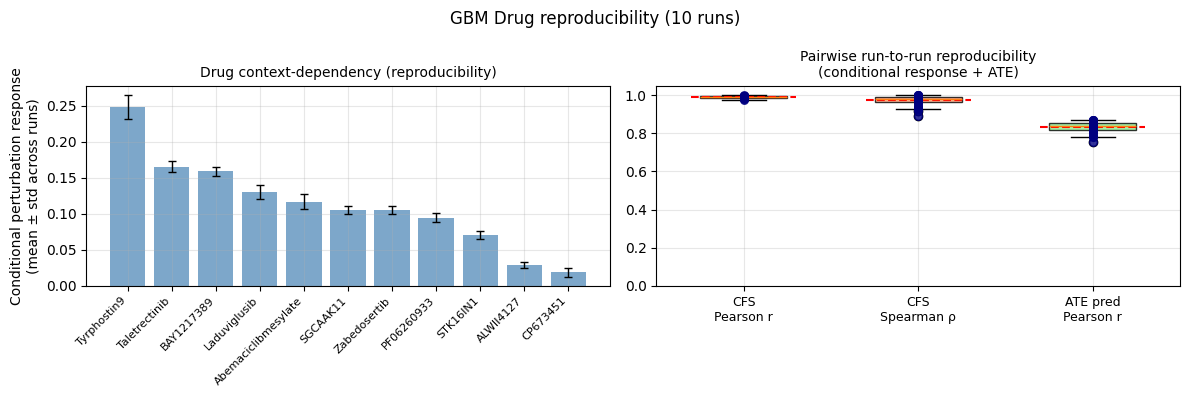

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: mean shift ± std
ax = axes[0]
ax.bar(range(len(df_shift)), df_shift['mean_shift'], color='steelblue', alpha=0.7)
ax.errorbar(range(len(df_shift)), df_shift['mean_shift'],
            yerr=df_shift['std_shift'], fmt='none', color='black', capsize=3, lw=1)
ax.set_xticks(range(len(df_shift)))
ax.set_xticklabels(df_shift['perturbation'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Conditional perturbation response\n(mean ± std across runs)')
ax.set_title('Drug context-dependency (reproducibility)', fontsize=10)
ax.grid(True, alpha=0.3)

# Boxplot of pairwise CFS correlations
ax = axes[1]
for pos, (vals, title, fc) in enumerate([
    (cfs_pearson,  'Pearson r',   'lightsteelblue'),
    (cfs_spearman, 'Spearman ρ',  'lightsalmon'),
    (ate_pred_corrs, 'ATE pred\nPearson r', 'lightgreen'),
], 1):
    clean = [v for v in vals if np.isfinite(v)]
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=fc, alpha=0.8))
    ax.scatter([pos]*len(clean), clean, s=30, color='navy', zorder=3, alpha=0.8)
    m = np.mean(clean)
    ax.plot([pos-0.3, pos+0.3], [m, m], 'r--', lw=1.5, label=f'mean={m:.3f}')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['CFS\nPearson r', 'CFS\nSpearman ρ', 'ATE pred\nPearson r'], fontsize=9)
ax.set_title('Pairwise run-to-run reproducibility\n(conditional response + ATE)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

fig.suptitle(f'GBM Drug reproducibility ({N_RUNS} runs)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/cfs_ate_reproducibility.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 7 — Perturbation-to-target bipartite reproducibility

The `counterfactual_effect_size` (shape P × G per condition) encodes the predicted
effect of each drug on each gene in each condition.  

We measure pairwise Pearson r of the full P×G matrices (flattened) across runs,
separately per condition.

In [16]:
cf_corrs_per_cond = {c: [] for c in cond_names}

for ci, cname in enumerate(cond_names):
    for i, j in pairs:
        xi = run_results[i]['cf_sizes'][ci].ravel()
        xj = run_results[j]['cf_sizes'][ci].ravel()
        v  = np.isfinite(xi) & np.isfinite(xj)
        cf_corrs_per_cond[cname].append(pearsonr(xi[v], xj[v])[0] if v.sum() > 2 else np.nan)

print('Perturbation-to-target CF effect size Pearson r (pairwise, per condition):')
for cname, vals in cf_corrs_per_cond.items():
    clean = [v for v in vals if np.isfinite(v)]
    print(f'  {cname}: {np.mean(clean):.4f} ± {np.std(clean):.4f}')

Perturbation-to-target CF effect size Pearson r (pairwise, per condition):
  NoT: 0.8422 ± 0.0700
  0.5T: 0.9303 ± 0.0473


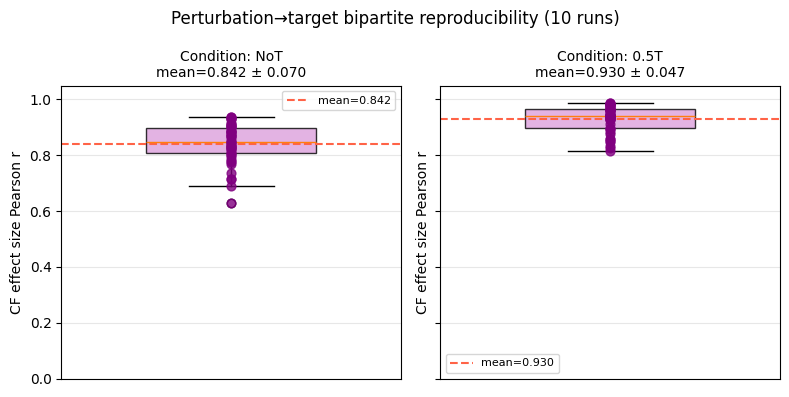

In [17]:
n_c = len(cond_names)
fig, axes = plt.subplots(1, n_c, figsize=(4 * n_c, 4), sharey=True)
if n_c == 1:
    axes = [axes]

for ax, cname in zip(axes, cond_names):
    vals  = cf_corrs_per_cond[cname]
    clean = [v for v in vals if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='plum', alpha=0.8))
    ax.scatter([1]*len(clean), clean, s=40, color='purple', zorder=3, alpha=0.8)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', lw=1.5, ls='--', label=f'mean={m:.3f}')
    ax.set_title(f'Condition: {cname}\nmean={m:.3f} ± {np.std(clean):.3f}', fontsize=10)
    ax.set_xticks([])
    ax.set_ylabel('CF effect size Pearson r')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Perturbation→target bipartite reproducibility ({N_RUNS} runs)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/cf_bipartite_reproducibility.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 7b — ev_sig significant gene-set reproducibility

For each condition, compare the sets of significant (perturbation, gene) pairs
(q < 0.05) across runs using Jaccard similarity.  
This directly tests whether the bipartite graph findings are consistent.

## Part 8 — Summary: all metrics

Consolidated view of all pairwise reproducibility metrics.

In [19]:
metric_labels = (['W co-act.', 'rho', 'Jaccard (raw)', 'Jaccard (aln)',
                   'ATE pred'] +
                  [f'CF ({c})' for c in cond_names] +
                  ['CFS Pearson', 'CFS Spearman'])
metric_vals   = ([w_corrs, rho_corrs, jac_raw, jac_aln, ate_pred_corrs] +
                  [cf_corrs_per_cond[c] for c in cond_names] +
                  [cfs_pearson, cfs_spearman])

rows = []
for label, vals in zip(metric_labels, metric_vals):
    clean = [v for v in vals if np.isfinite(v)]
    rows.append({'metric': label, 'mean': np.mean(clean),
                 'std': np.std(clean), 'min': np.min(clean), 'max': np.max(clean)})
summary_df = pd.DataFrame(rows).set_index('metric')
print('Reproducibility summary (all pairwise run comparisons):')
print(summary_df.round(4).to_string())

Reproducibility summary (all pairwise run comparisons):
                 mean     std     min     max
metric                                       
W co-act.      0.8865  0.0425  0.7542  0.9581
rho            0.8168  0.0960  0.5656  0.9372
Jaccard (raw)  0.3428  0.1352  0.1481  0.8095
Jaccard (aln)  0.3428  0.1352  0.1481  0.8095
ATE pred       0.8335  0.0264  0.7519  0.8710
CF (NoT)       0.8422  0.0700  0.6304  0.9370
CF (0.5T)      0.9303  0.0473  0.8137  0.9882
CFS Pearson    0.9896  0.0054  0.9735  0.9980
CFS Spearman   0.9743  0.0252  0.8909  1.0000


In [20]:
EV_ALPHA = 0.05

evsig_jaccard_per_cond = {c: [] for c in cond_names}

for ci, cname in enumerate(cond_names):
    # Build set of significant (pert_idx, gene_idx) pairs per run
    sig_sets = []
    for rr in run_results:
        qv   = rr['ev_qvals'][ci]      # (P, G)
        idxs = set(zip(*np.where(qv < EV_ALPHA)))
        sig_sets.append(idxs)

    for i, j in pairs:
        si, sj = sig_sets[i], sig_sets[j]
        union  = si | sj
        inter  = si & sj
        jac    = len(inter) / len(union) if union else np.nan
        evsig_jaccard_per_cond[cname].append(jac)

print(f'ev_sig Jaccard (q<{EV_ALPHA}, significant pert×gene pairs) per condition:')
for cname, vals in evsig_jaccard_per_cond.items():
    clean = [v for v in vals if np.isfinite(v)]
    print(f'  {cname}: {np.mean(clean):.4f} ± {np.std(clean):.4f}'
          f'  (min={np.min(clean):.4f}  max={np.max(clean):.4f})')

# Add ev_sig Jaccard to the metric lists for the summary boxplot
for cname in cond_names:
    label = f'ev_sig Jac ({cname})'
    if label not in metric_labels:
        metric_labels.append(label)
        metric_vals.append(evsig_jaccard_per_cond[cname])

ev_sig Jaccard (q<0.05, significant pert×gene pairs) per condition:
  NoT: 0.4767 ± 0.0303  (min=0.4018  max=0.5448)
  0.5T: 0.4538 ± 0.0236  (min=0.4146  max=0.4912)


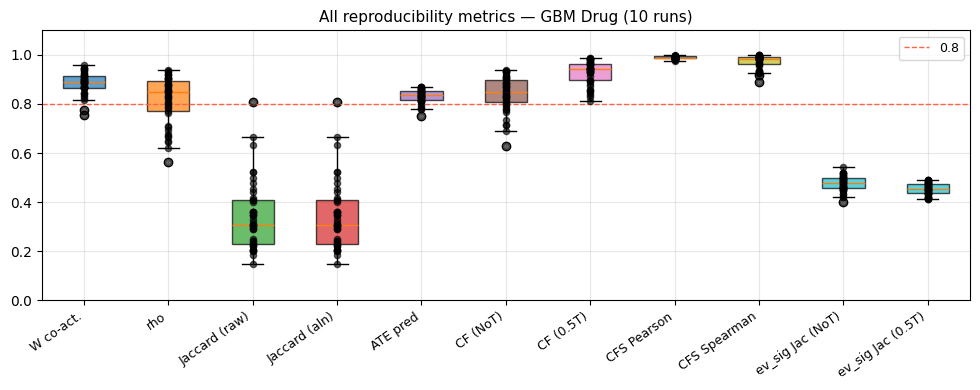

In [21]:
n_m  = len(metric_labels)
fig, ax = plt.subplots(figsize=(max(8, n_m * 0.9), 4))
colors = plt.cm.tab10(np.linspace(0, 1, n_m))

for pos, (label, vals, col) in enumerate(zip(metric_labels, metric_vals, colors), 1):
    clean = [v for v in vals if np.isfinite(v)]
    if not clean:
        continue
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.7))
    ax.scatter([pos]*len(clean), clean, s=20, color='k', zorder=3, alpha=0.6)

ax.set_xticks(range(1, n_m + 1))
ax.set_xticklabels(metric_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='tomato', ls='--', lw=1, label='0.8')
ax.legend(fontsize=9)
ax.set_title(f'All reproducibility metrics — GBM Drug ({N_RUNS} runs)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/all_metrics_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 9 — Best model: recapitulate key figures

Load the best-ATE model and regenerate the key figures from
`gbm_run_conditions_bt333_with_T_cell_conditions_figures_10um.ipynb`.

In [24]:
best_model = slk.tl.load_results(f'{RESULTS_DIR}/matrices/best_model.pth')

if hasattr(data.X, 'toarray'):
    data.X = data.X.toarray()

slk.tl.eval_single(best_model, data, obsm_key='z', uns_key='results', device=DEVICE)

best_run_loaded = int(np.loadtxt(f'{RESULTS_DIR}/matrices/best_run.txt'))
best_ate_r_val  = float(np.loadtxt(f'{RESULTS_DIR}/matrices/best_ate_r.txt'))
print(f'Loaded best model from run {best_run_loaded+1} (ATE r={best_ate_r_val:.4f})')

Loaded best model from run 10 (ATE r=0.7265)


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


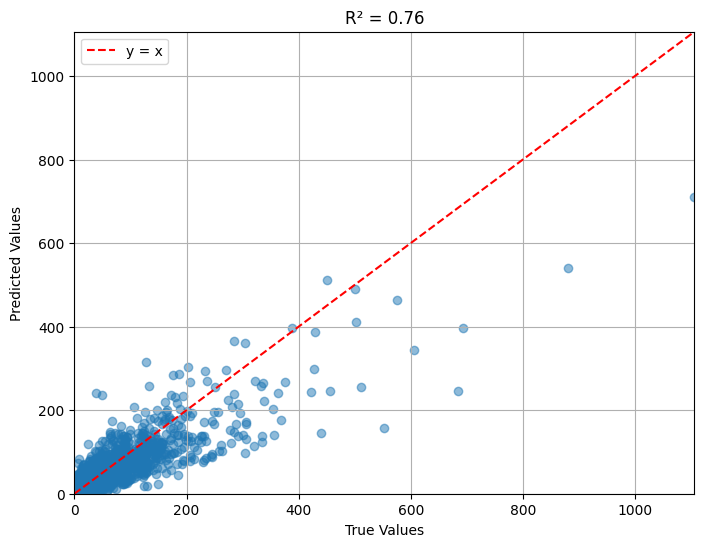

<Figure size 640x480 with 0 Axes>

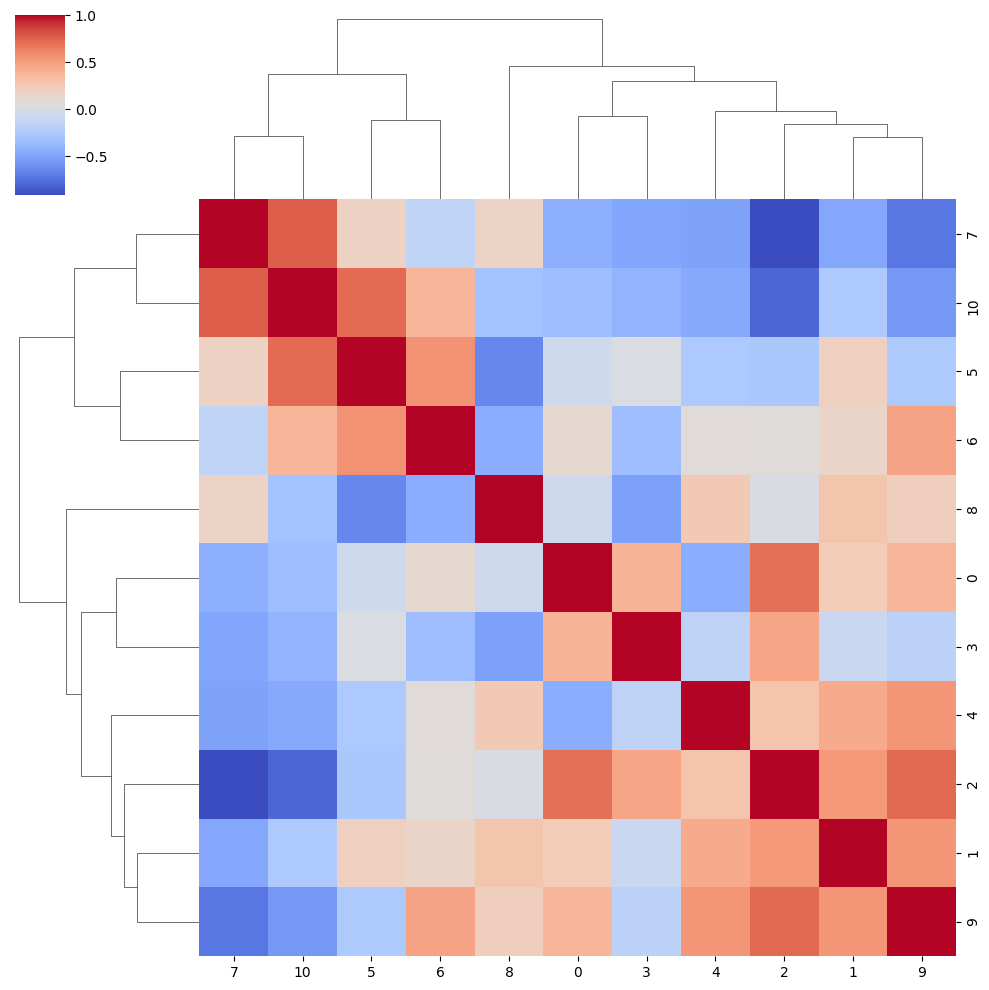

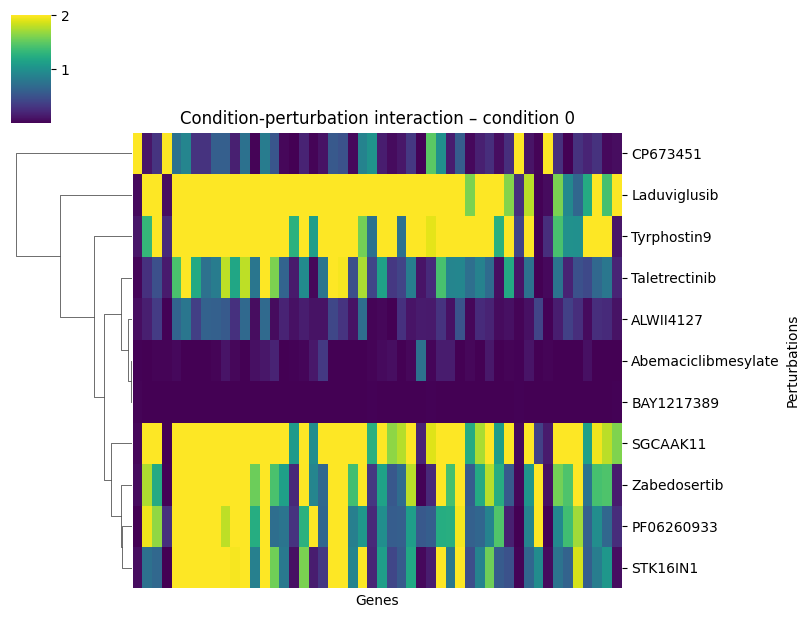

<Figure size 640x480 with 0 Axes>

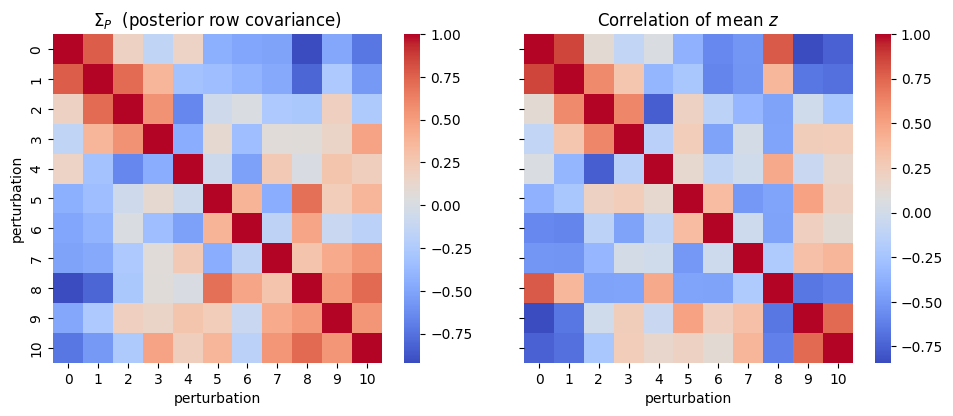

<Figure size 640x480 with 0 Axes>

In [25]:
# R², rho correlation, EV (eigenvalue ranking)
slk.pl.plot_r2(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_r2.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_corr(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_rho_corr.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_ev(data, cmax=2, top_n=50)
plt.savefig(f'{RESULTS_DIR}/figures/best_ev.png', bbox_inches='tight', dpi=150)
plt.show()

slk.pl.plot_zcorr(data)
plt.savefig(f'{RESULTS_DIR}/figures/best_zcorr.png', bbox_inches='tight', dpi=150)
plt.show()

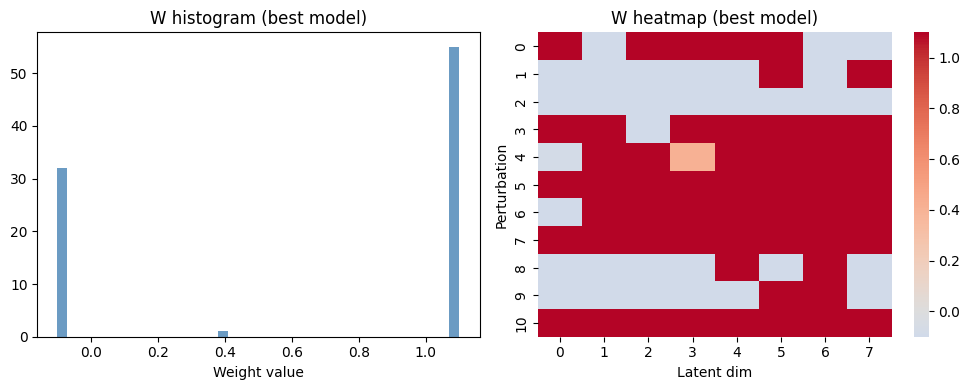

In [26]:
# W matrix
W_best = data.uns['results']['W']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(W_best.flatten(), bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('W histogram (best model)')
axes[0].set_xlabel('Weight value')
sns.heatmap(W_best, ax=axes[1], cmap='coolwarm', center=0)
axes[1].set_title('W heatmap (best model)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_W.png', bbox_inches='tight', dpi=150)
plt.show()

show=True is only supported for criterion='distance'. Ignoring.

Best model clustering (N_CLUSTERS=3):
  Group 1 (4): ['PF06260933', 'SGCAAK11', 'STK16IN1', 'Zabedosertib']
  Group 2 (2): ['ALWII4127', 'CP673451']
  Group 3 (5): ['Abemaciclibmesylate', 'BAY1217389', 'Laduviglusib', 'Taletrectinib', 'Tyrphostin9']


<Figure size 640x480 with 0 Axes>

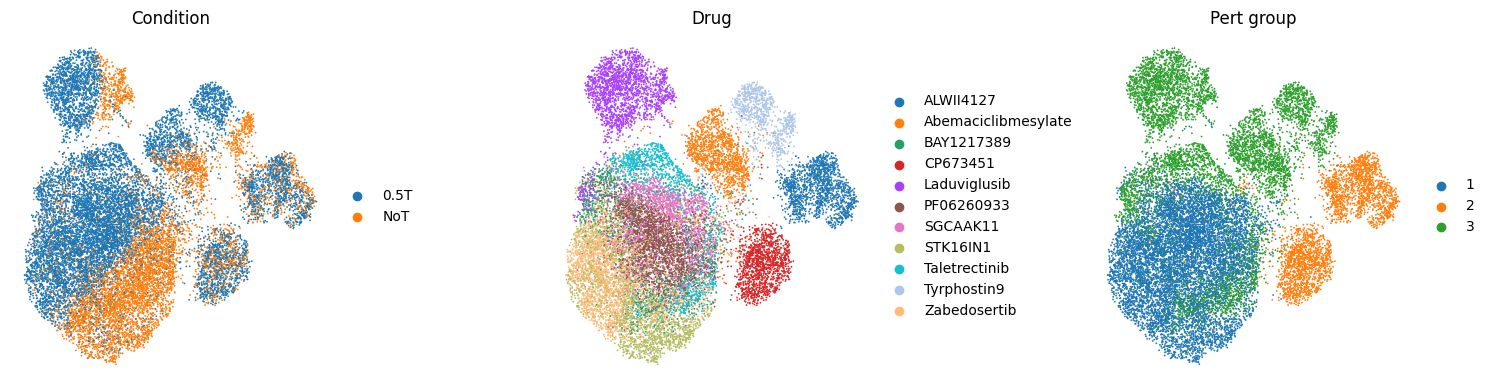

In [27]:
# Perturbation clustering + UMAP (best model)
groups       = slk.tl.cluster_rho(data, t=N_CLUSTERS, criterion='maxclust', show=True)
dataset      = slk.tl.PerturbMatchingDataset(data)
all_genes    = list(dataset.perturbation_dict.keys())
named_groups = slk.tl.group2name(groups, all_genes)

print(f'\nBest model clustering (N_CLUSTERS={N_CLUSTERS}):')
for g in sorted(named_groups['group'].unique()):
    members = sorted(named_groups[named_groups['group'] == g].index.tolist())
    print(f'  Group {g} ({len(members)}): {members}')

plt.savefig(f'{RESULTS_DIR}/figures/best_dendrogram_k{N_CLUSTERS}.png', bbox_inches='tight', dpi=150)
plt.show()

# UMAP of latent z-space coloured by drug, condition, and cluster group
sub = data[data.obs[p_key] != NTC].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z', random_state=0)
sc.tl.umap(sub, random_state=0)

gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(sub, color=c_key,        frameon=False, ax=axes[0], show=False, title='Condition')
sc.pl.umap(sub, color=p_key,        frameon=False, ax=axes[1], show=False, title='Drug', legend_loc='right margin')
sc.pl.umap(sub, color='pert_group', frameon=False, ax=axes[2], show=False, title='Pert group')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap.png', bbox_inches='tight', dpi=150)
plt.show()

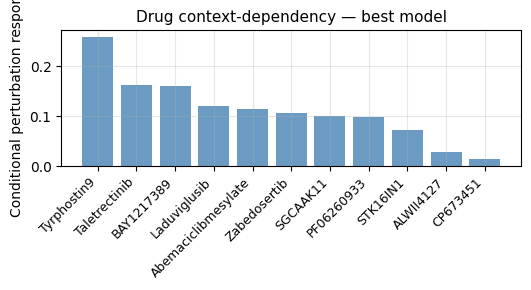

In [29]:
# Conditional perturbational response (CFS bar chart) — best model
res       = data.uns['results']
pert_names = list(res['rho_perts'])
cfs_best   = np.asarray(res['condition_perturbation_interaction'], dtype=float)
cond_best  = list(res['conditions'])

n_c       = len(cond_best)
mask_c    = np.triu(np.ones((n_c, n_c)), k=1).astype(bool)
avg_shift = np.array([cfs_best[p][mask_c].mean() for p in range(len(pert_names))])

df_sens = pd.DataFrame({
    'perturbation': pert_names,
    'condition_effect': avg_shift,
}).sort_values('condition_effect', ascending=False)

fig, ax = plt.subplots(figsize=(max(4, len(pert_names) * 0.5), 3))
ax.bar(range(len(df_sens)), df_sens['condition_effect'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(df_sens)))
ax.set_xticklabels(df_sens['perturbation'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Conditional perturbation response')
ax.set_title('Drug context-dependency — best model', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_cfs_bar.png', bbox_inches='tight', dpi=150)
plt.show()

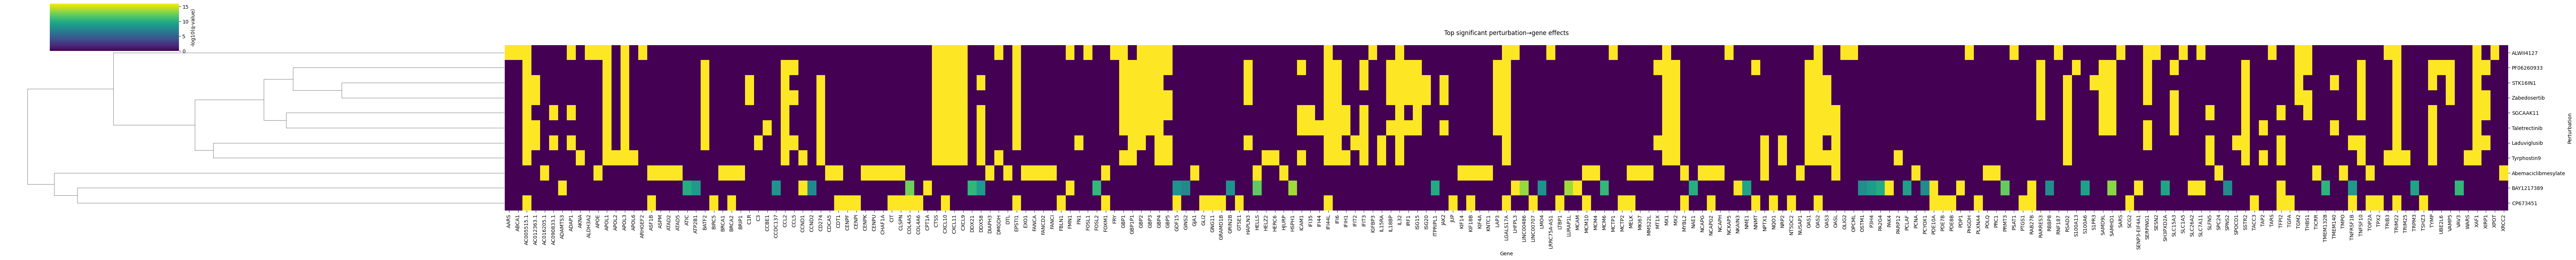

<Figure size 640x480 with 0 Axes>



<Figure size 640x480 with 0 Axes>

In [30]:
# EV significance heatmap per condition
cond_labels_best = data.uns['results']['conditions']
for cond_idx, cond_label in enumerate(cond_labels_best):
    slk.tl.ev_sig(data, cond_idx=cond_idx)
    try:
        slk.pl.plot_ev_sig(
            data, cond_idx=cond_idx, uns_key='results',
            alpha=0.05, top_n_genes=50, min_sig_genes=3,
            cluster_rows=True, cluster_cols=False,
        )
        plt.savefig(f'{RESULTS_DIR}/figures/best_ev_sig_{cond_label}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
    except Exception as e:
        print(f'  Condition {cond_label}: {e}')

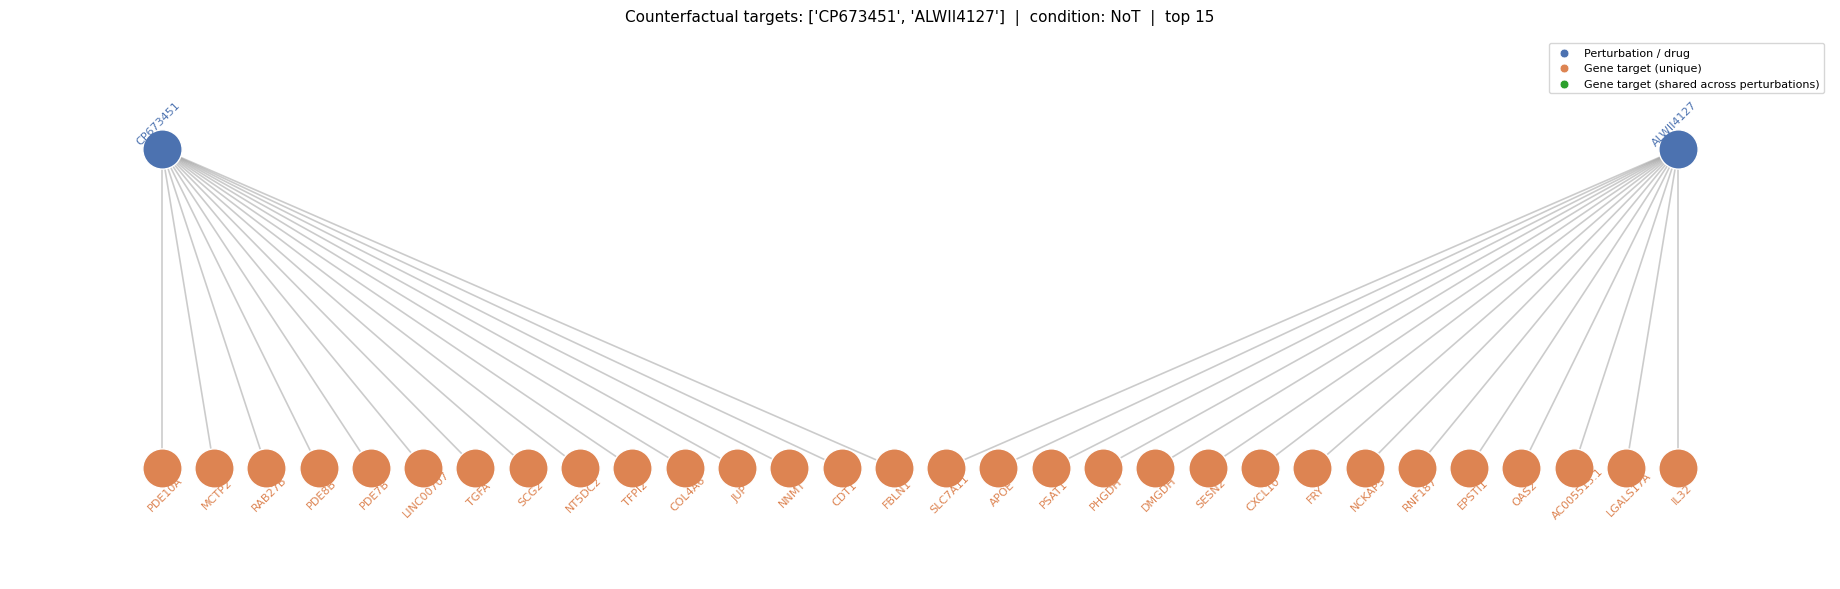

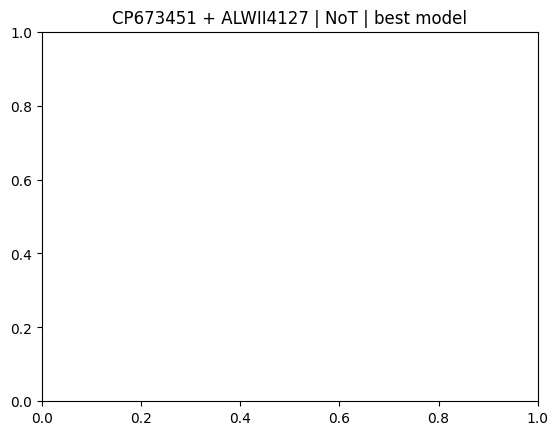

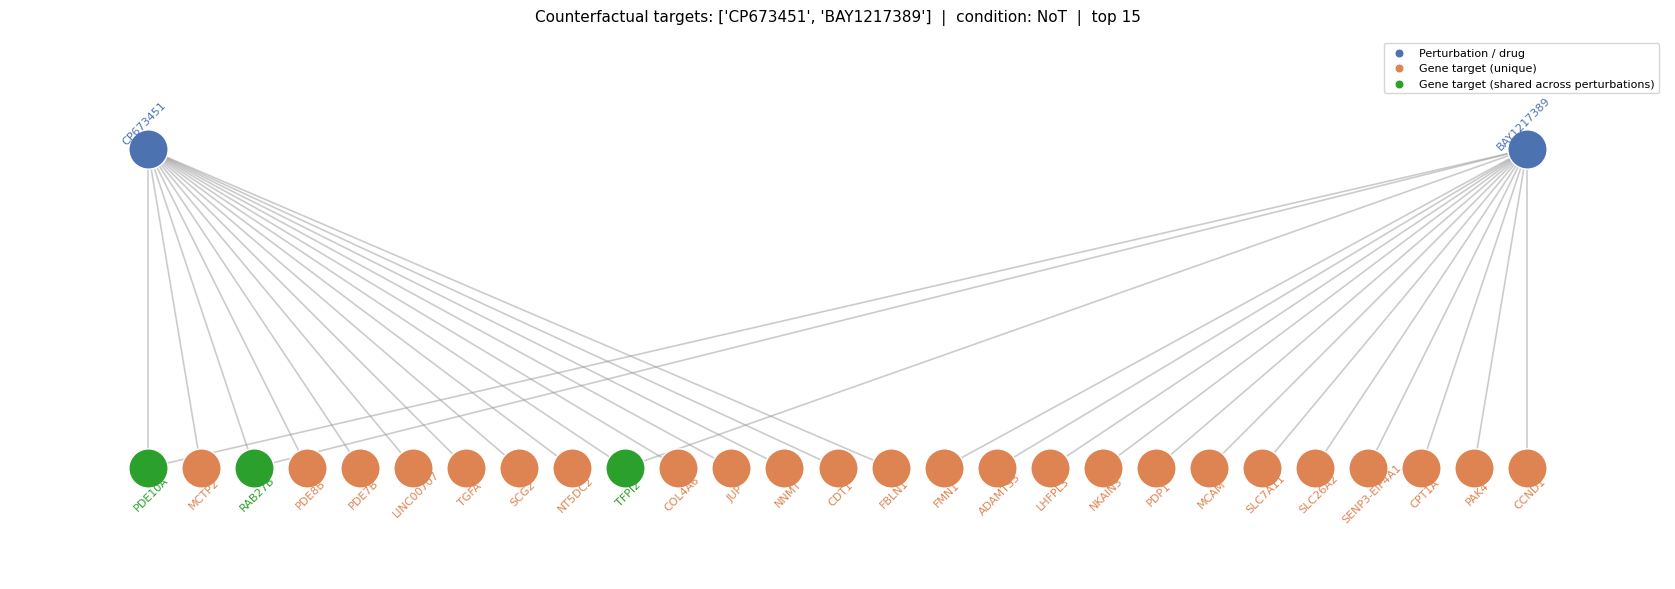

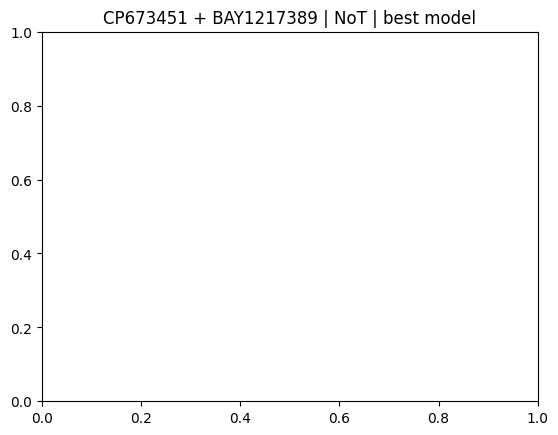

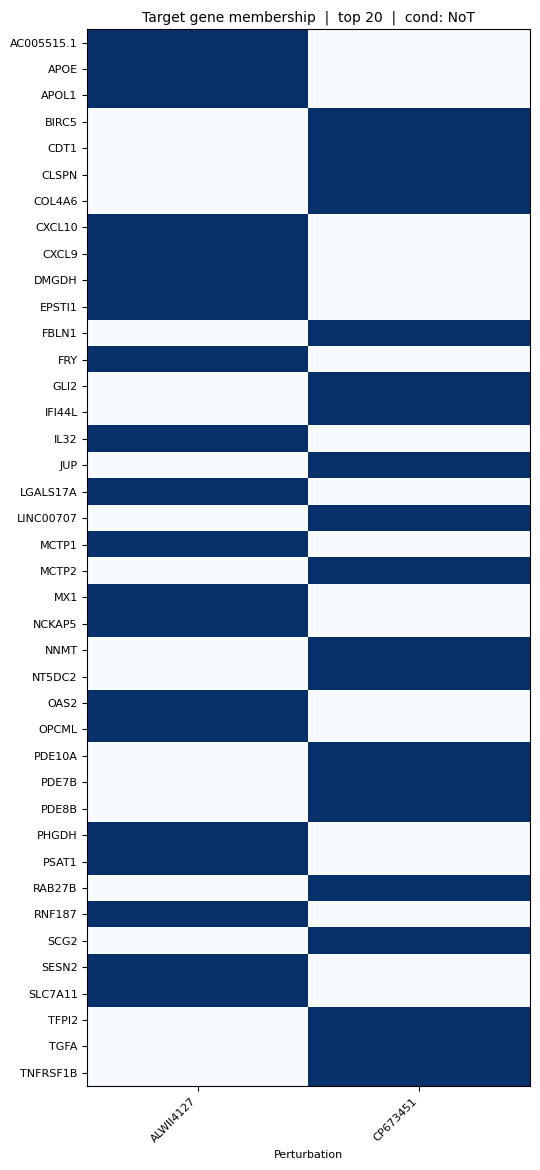

<Figure size 640x480 with 0 Axes>

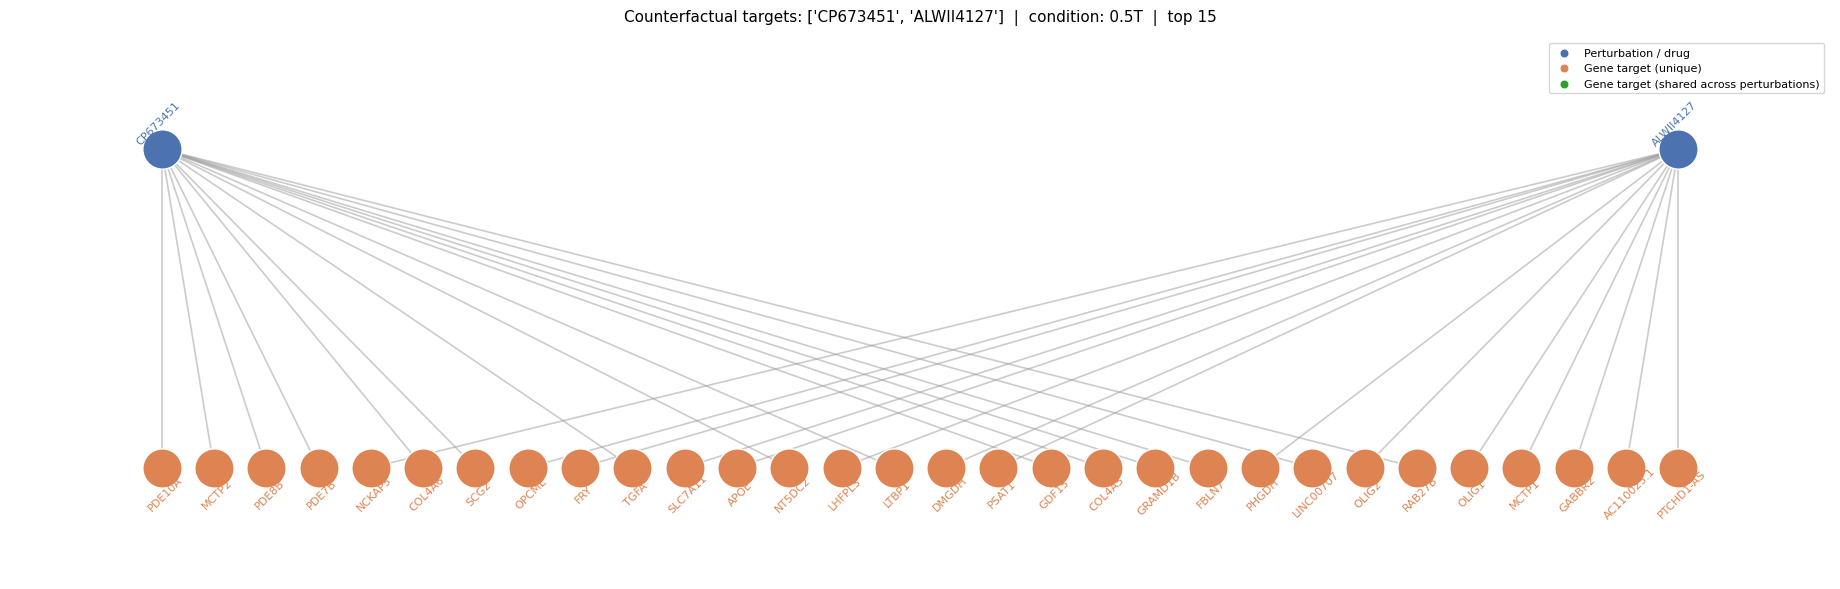

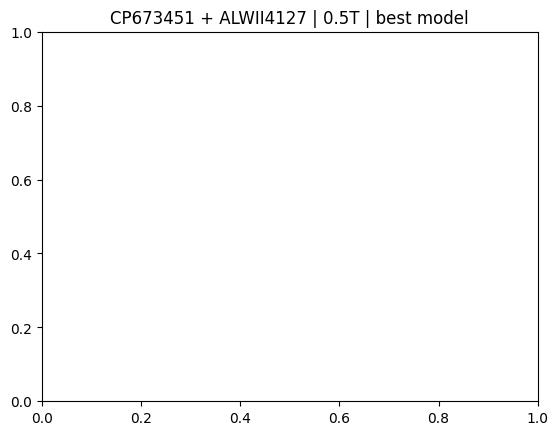

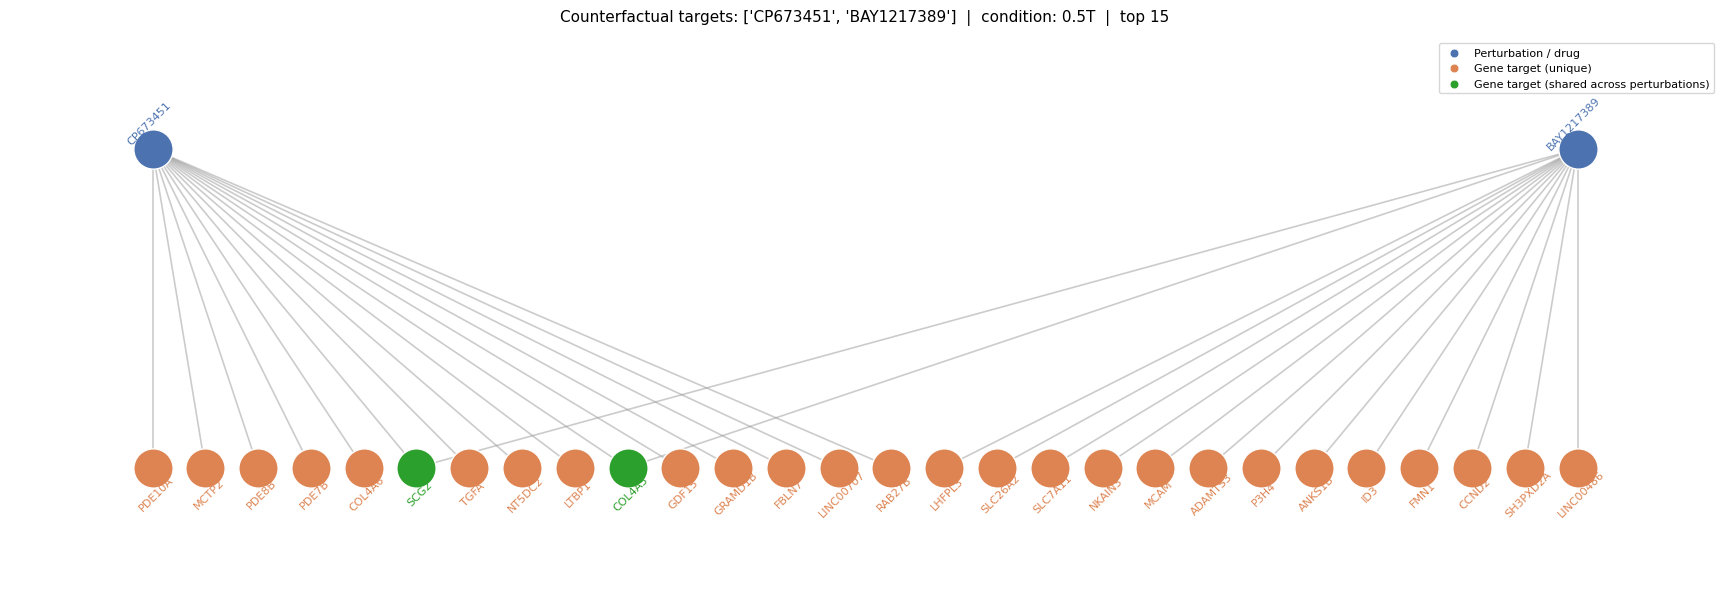

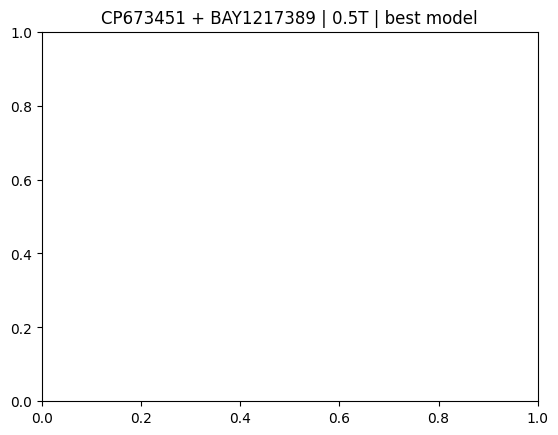

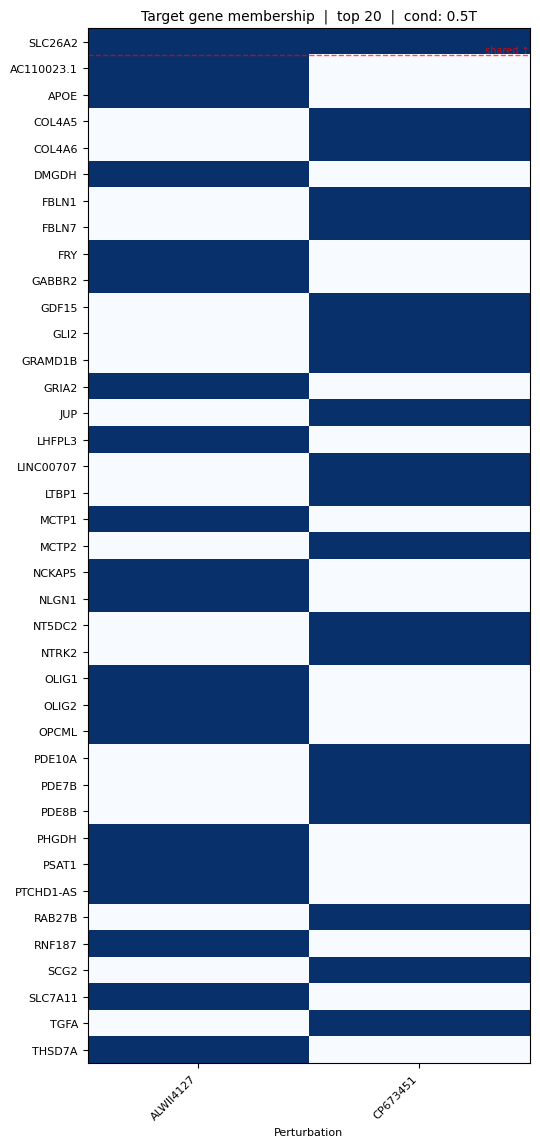

<Figure size 640x480 with 0 Axes>

In [31]:
# Perturbation → target bipartite graphs per condition
# Individual drugs + joint pairs matching the original notebook
cond_labels_best = data.uns['results']['conditions']

for cond_idx, cond_label in enumerate(cond_labels_best):
    # Joint: CP673451 + ALWII4127 (matches original fig cell 65)
    slk.pl.plot_cf_bipartite(
        data, cond_idx=cond_idx,
        pert_name=['CP673451', 'ALWII4127'], top_n=15,
    )
    plt.title(f'CP673451 + ALWII4127 | {cond_label} | best model')
    plt.savefig(f'{RESULTS_DIR}/figures/best_bipartite_CP_AL_{cond_label}.png',
                bbox_inches='tight', dpi=150)
    plt.show()

    # Joint: CP673451 + BAY1217389 (matches original fig cell 66)
    try:
        slk.pl.plot_cf_bipartite(
            data, cond_idx=cond_idx,
            pert_name=['CP673451', 'BAY1217389'], top_n=15,
        )
        plt.title(f'CP673451 + BAY1217389 | {cond_label} | best model')
        plt.savefig(f'{RESULTS_DIR}/figures/best_bipartite_CP_BAY_{cond_label}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
    except Exception as e:
        print(f'  BAY1217389 / {cond_label}: {e}')

    # Target overlap (gene × drug membership matrix) — matches original cells 69/70
    slk.pl.plot_cf_target_overlap(
        data, cond_idx=cond_idx, top_n=20,
        pert_names=['CP673451', 'ALWII4127'],
        show_jaccard=False, show_membership=True,
    )
    plt.savefig(f'{RESULTS_DIR}/figures/best_cf_target_overlap_{cond_label}.png',
                bbox_inches='tight', dpi=150)
    plt.show()

In [32]:
# Shared significant gene analysis per condition (matches original notebook cell 32)
# Genes significantly regulated by BOTH ALWII4127 and CP673451
alpha = 0.05
cond_labels_best = data.uns['results']['conditions']

for cond_idx, cond_label in enumerate(cond_labels_best):
    slk.tl.ev_sig(data, cond_idx=cond_idx)
    df_ev     = slk.pl.make_ev_long_df(data, cond_idx=cond_idx, uns_key='results')
    df_ev_sig = df_ev[df_ev['qval'] < alpha]

    genes_AL = set(df_ev_sig[df_ev_sig['pert'] == 'ALWII4127']['gene'])
    genes_CP = set(df_ev_sig[df_ev_sig['pert'] == 'CP673451']['gene'])
    shared   = genes_AL & genes_CP

    print(f'\nCondition: {cond_label}')
    print(f'  Sig genes ALWII4127 : {len(genes_AL)}')
    print(f'  Sig genes CP673451  : {len(genes_CP)}')
    print(f'  Shared genes        : {len(shared)}')

    if shared:
        df_shared = (
            df_ev_sig[df_ev_sig['gene'].isin(shared) &
                      df_ev_sig['pert'].isin(['ALWII4127', 'CP673451'])]
            [['pert', 'gene', 'ev', 'qval']]
            .pivot(index='gene', columns='pert', values=['ev', 'qval'])
            .sort_values(('ev', 'ALWII4127'), ascending=False)
        )
        df_shared.columns = ['ev_AL', 'ev_CP', 'qval_AL', 'qval_CP']
        print(df_shared.round(4).to_string())


Condition: NoT
  Sig genes ALWII4127 : 622
  Sig genes CP673451  : 559
  Shared genes        : 164
             ev_AL    ev_CP  qval_AL  qval_CP
gene                                         
PHGDH       0.8859   0.3576   0.0000   0.0000
CXCL10      0.7853   0.9106   0.0000   0.0000
EPSTI1      0.7122   0.8950   0.0000   0.0000
OAS2        0.6812   0.8282   0.0000   0.0000
AC005515.1  0.6767   0.7465   0.0000   0.0000
LGALS17A    0.6442   0.7511   0.0000   0.0000
IL32        0.6182   0.2939   0.0000   0.0000
CXCL9       0.6066   0.6011   0.0000   0.0000
OPCML       0.6043   0.2661   0.0000   0.0000
MX1         0.5565   0.6014   0.0000   0.0000
APOL1       0.5136   0.5831   0.0000   0.0000
MCTP1       0.4441   0.4202   0.0000   0.0000
SERPING1    0.4342   0.2967   0.0000   0.0000
XAF1        0.4243   0.5534   0.0000   0.0000
GBP1        0.4156   0.6693   0.0000   0.0000
TRIM22      0.3911   0.8323   0.0000   0.0000
CXCL11      0.3678   0.2947   0.0000   0.0000
GBP5        0.3479   0.302

## Part 10 — UMAP (best model, publication style)

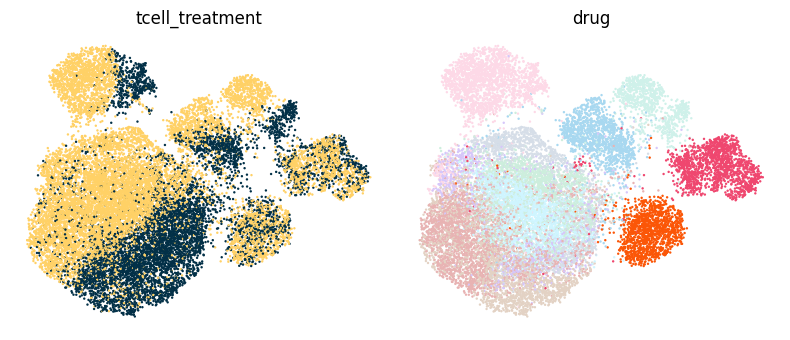

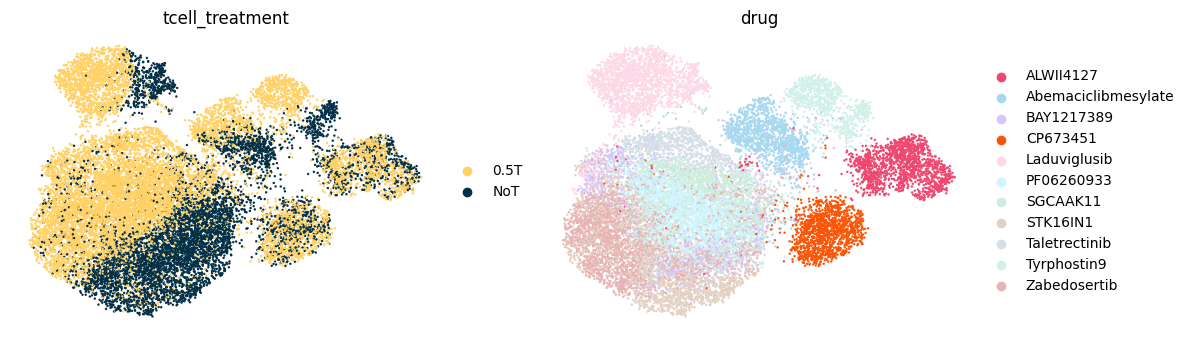

In [33]:
import random

palette1 = ["#FFD166", "#023047"]

palette2_very_light = [
    "#EF476F",  # keep
    "#A8D8F0",  # very light blue
    "#D6C7FA",  # very light purple
    "#FB5607",  # keep
    "#FDD9E7",  # very light pink
    "#CFF5FF",  # very light cyan
    "#CDEEDD",  # very light green
    "#E3D2C4",  # very light brown
    "#D6DEE8",  # very light gray-blue
    "#CFF1EA",  # very light teal
    "#E8B3B3",  # very light dark red
]

# Recompute sub/UMAP from best model z-space (in case this cell is run standalone)
sub = data[data.obs[p_key] != NTC].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z', random_state=0)
sc.tl.umap(sub, random_state=0)

# ── compact, no legends ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
sc.pl.umap(sub, color=c_key, title=c_key,
           palette=palette1,          size=12, frameon=False,
           ax=axes[0], show=False, legend_loc=None)
sc.pl.umap(sub, color=p_key, title=p_key,
           palette=palette2_very_light, size=12, frameon=False,
           ax=axes[1], show=False, legend_loc=None)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace.png',        bbox_inches='tight', dpi=300)
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace.svg',        bbox_inches='tight', dpi=300)
plt.show()

# ── with legends ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sc.pl.umap(sub, color=c_key, title=c_key,
           palette=palette1,          size=12, frameon=False,
           ax=axes[0], show=False)
sc.pl.umap(sub, color=p_key, title=p_key,
           palette=palette2_very_light, size=12, frameon=False,
           ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace_with_legends.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{RESULTS_DIR}/figures/best_umap_zspace_with_legends.svg', bbox_inches='tight', dpi=300)
plt.show()